# Stack, or where you're Stacked?: A 2024 Stack Overflow Survey Analysis

- by: Gabriel Anthony DG. Gilo 
(originally written on 12/11/2025)

**Data:** 2024 Stack Overflow Developer Survey. 165,437 respondents, 185 countries. Filtered to 19,990 professional developers with valid pay and experience data. [Source](https://survey.stackoverflow.co/2024/)

**Tools:** Python, pandas, scikit-learn (Ridge, Random Forest), seaborn/matplotlib.

## Introduction

The 2024 Stack Overflow Developer Survey is one of the most-cited datasets in tech hiring conversations, used to argue everything from which language to learn to whether remote work pays better. This case study tests those claims directly: does location, experience, tech stack, or remote status actually move the needle on pay and job satisfaction, or do the popular narratives fall apart once the obvious confounds are controlled for?

## Questions we want to answer

- Do technical skill choices (like programming languages) and work modalities (like remote work) independently drive higher compensation, or are those pay differences mostly explained by location and experience?

- How much predictive power do standard variables, such as location and tenure, actually hold when estimating global developer pay, and how much variance remains unexplained?

- What factors actually correlate with high job satisfaction among professional developers: financial compensation, or daily operational workflow efficiency?

- How effectively can standard predictive algorithms, like Ridge Regression and Random Forest models, estimate developer salaries, and where do those models run into limitations?


## Summary

This survey gets cited a lot to back up claims about what developers should learn, where they should work, and what companies should pay them. Most of those claims don't hold up once you control for the obvious confounds. Five things stood out:

1. Country and years of experience account for almost all of what a regression model can explain about pay (R² ≈ 0.54). Education and remote status barely move the needle once those two are known.
2. Languages like Go and Rust look like they pay more, but developers who use them also tend to be more senior. Once experience and country are in the model, no single language explains more than about 1% of the pay variance.
3. Job satisfaction correlates more with day-to-day friction (knowledge silos, trouble finding answers) than with pay. That holds even after controlling for country, though the gap between friction and pay narrows once the comparison is made fairly.
4. Remote workers report higher pay than in-person workers, even within a single country. Part of that gap is real. Part of it is that remote workers in this sample are also more senior.
5. A five-fold cross-validated Random Forest edges out a plain Ridge regression by about two points of R² (0.56 vs. 0.54), not much return for a much heavier model. The bigger issue: even the better model is off by about 50% on a typical prediction, and it's worse than that for developers in lower-income countries.


In [1]:
# Setup
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from adjustText import adjust_text

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
PRIMARY_COLOR = '#1f77b4'
ACCENT_COLOR = '#ff7f0e'
TEXT_COLOR = '#2c3e50'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'figure.dpi': 120,
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.labelcolor': TEXT_COLOR,
    'text.color': TEXT_COLOR,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 14
})

print("Setup done.")

Setup done.


## Data Cleaning

Cleaning steps, applied before any analysis:

- Keep only respondents who selected "I am a developer by profession." This drops students, hobbyists, and former developers.
- Keep annual compensation between \$5,000 and \$500,000. This removes data-entry errors and outliers that would otherwise dominate every summary statistic.
- Convert experience text buckets ("Less than 1 year," "More than 50 years") into numbers: 0.5 and 50.
- Drop rows with no usable experience value.

Compensation gets a log10 transform before it goes into any linear model, since raw pay is heavily right-skewed.

In [2]:
def load_and_preprocess_data(filepath='survey_results_public.csv'):
    usecols = [
        'ResponseId', 'MainBranch', 'Country', 'YearsCodePro', 'RemoteWork', 'EdLevel',
        'ConvertedCompYearly', 'LanguageHaveWorkedWith', 'AISent', 'AIAcc', 'AIThreat',
        'JobSat', 'Knowledge_2', 'Knowledge_4'
    ]

    df = pd.read_csv(filepath, usecols=usecols)
    initial_count = len(df)

    # Professional developers only
    df_prof = df[df['MainBranch'] == 'I am a developer by profession'].copy()

    # Experience buckets -> numeric years
    def convert_years(val):
        if pd.isna(val): return np.nan
        if val == 'Less than 1 year': return 0.5
        if val == 'More than 50 years': return 50.0
        try: return float(val)
        except: return np.nan

    df_prof['YearsCodePro_num'] = df_prof['YearsCodePro'].apply(convert_years)

    # Compensation window: $5,000 - $500,000
    df_clean = df_prof[
        (df_prof['ConvertedCompYearly'] >= 5000) &
        (df_prof['ConvertedCompYearly'] <= 500000) &
        (df_prof['YearsCodePro_num'].notna())
    ].copy()

    df_clean['LogComp'] = np.log10(df_clean['ConvertedCompYearly'])

    print(f"Data cleaning audit:")
    print(f"- Total raw survey responses: {initial_count:,}")
    print(f"- Professional developers: {len(df_prof):,} ({len(df_prof)/initial_count:.1%})")
    print(f"- Cleaned analysis dataset (valid pay & experience): {len(df_clean):,}")

    return df_clean

df_clean = load_and_preprocess_data()

Data cleaning audit:
- Total raw survey responses: 65,437
- Professional developers: 50,207 (76.7%)
- Cleaned analysis dataset (valid pay & experience): 19,990


## Exploratory Data Analysis

Before testing any specific claim, it's worth looking at the cleaned dataset on its own terms: how big it is, what's missing, and what the core variables actually look like. This section doesn't test hypotheses, it just lays out what we're working with.


In [ ]:
print(f"Rows: {df_clean.shape[0]:,}")
print(f"Columns: {df_clean.shape[1]}")
print()
print("Column types:")
print(df_clean.dtypes)
print()
print("Missing values by column:")
missing = df_clean.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(1)
print(pd.DataFrame({'missing': missing, 'pct': missing_pct}))


`AISent`, `AIAcc`, and `AIThreat` carry the most missing values; those questions were conditional on earlier answers in the survey and aren't used in this analysis. `Knowledge_2` and `Knowledge_4` (used in Section 3) and `LanguageHaveWorkedWith` (used in Section 2) have some missingness too, which is why those sections filter down further before running their own comparisons.


In [ ]:
print("Numeric summary (pay and experience):")
display(df_clean[['ConvertedCompYearly', 'YearsCodePro_num']].describe().round(1))
print()
print("Top 10 countries by respondent count:")
print(df_clean['Country'].value_counts().head(10))
print()
print("Remote work distribution:")
print(df_clean['RemoteWork'].value_counts(dropna=False))
print()
print("Education level distribution:")
print(df_clean['EdLevel'].value_counts(dropna=False))


A few things stand out already. Median pay sits well below the mean, which is the first sign of the right-skew mentioned in the cleaning notes. `YearsCodePro_num` tops out at 50 because of how the "More than 50 years" bucket was coded, not because nobody has more experience than that. The country list is dominated by the US and a handful of other high-income countries, which is worth keeping in mind: the sample isn't a uniform slice of "developers worldwide," it's weighted toward wherever Stack Overflow's respondents happen to be concentrated.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Raw pay distribution -- shows the right-skew directly
axes[0, 0].hist(df_clean['ConvertedCompYearly'], bins=60, color=PRIMARY_COLOR, edgecolor='white', linewidth=0.3)
axes[0, 0].set_title('Annual compensation (raw)')
axes[0, 0].set_xlabel('USD')
axes[0, 0].set_ylabel('Respondents')
axes[0, 0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

# Log-transformed pay -- the shape the models actually see
axes[0, 1].hist(df_clean['LogComp'], bins=60, color=ACCENT_COLOR, edgecolor='white', linewidth=0.3)
axes[0, 1].set_title('Annual compensation (log10)')
axes[0, 1].set_xlabel('log10(USD)')
axes[0, 1].set_ylabel('Respondents')

# Years of professional experience
axes[1, 0].hist(df_clean['YearsCodePro_num'], bins=40, color=PRIMARY_COLOR, edgecolor='white', linewidth=0.3)
axes[1, 0].set_title('Years of professional experience')
axes[1, 0].set_xlabel('Years')
axes[1, 0].set_ylabel('Respondents')

# Respondent count by top 10 countries
top10 = df_clean['Country'].value_counts().head(10).sort_values()
axes[1, 1].barh(top10.index, top10.values, color=ACCENT_COLOR)
axes[1, 1].set_title('Respondents by country (top 10)')
axes[1, 1].set_xlabel('Respondents')

plt.tight_layout()
plt.show()


**Takeaway.** Raw pay is heavily right-skewed, which confirms why the log10 transform is used before anything goes into a linear model; the log-scale histogram is much closer to symmetric. Experience is concentrated in the early-to-mid career range, with a long thin tail out toward 50 years. The country breakdown makes it clear this is a US-heavy sample with a long tail of everywhere else, which is the reason country gets treated as its own variable rather than assumed away in every section that follows.

With a working picture of the dataset in place, the rest of the notebook moves into testing specific claims about pay and satisfaction.


## 1. What Predicts Pay: Country, Experience, or Remote Work?

A common claim in tech hiring content: pick the right stack or negotiate remote work, and pay takes care of itself. This section checks that against the five countries with the most respondents (the US, UK, Germany, Canada, and India), split by experience level. Remote work gets checked separately, first pooled across all five countries, then again inside the US only, to see whether the pattern survives once country is no longer doing the work.

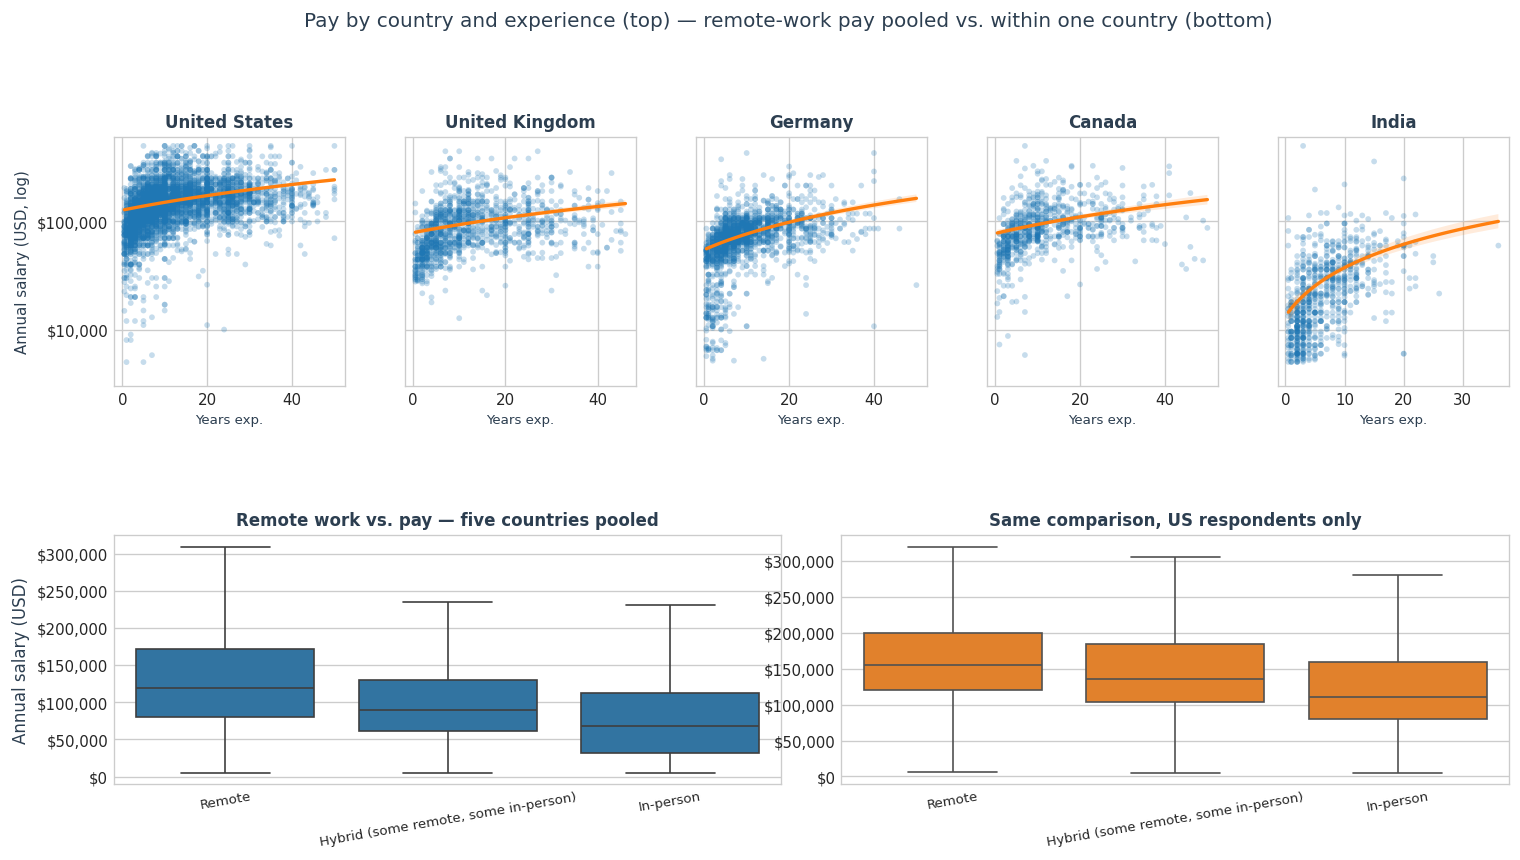

Country
United States of America                                145000.0
Canada                                                   87231.0
United Kingdom of Great Britain and Northern Ireland     84904.0
Germany                                                  74110.0
India                                                    21534.0
Name: ConvertedCompYearly, dtype: float64

US only, by remote status (median pay and median experience):
                                      ConvertedCompYearly  YearsCodePro_num
RemoteWork                                                                 
Remote                                           155000.0              12.0
Hybrid (some remote, some in-person)             136000.0               8.0
In-person                                        110000.0               7.0


In [3]:
top_countries = ['United States of America', 'United Kingdom of Great Britain and Northern Ireland',
                  'Germany', 'Canada', 'India']
country_labels = {'United States of America': 'United States',
                   'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
                   'Germany': 'Germany', 'Canada': 'Canada', 'India': 'India'}

df_top_countries = df_clean[df_clean['Country'].isin(top_countries)].copy()

fig = plt.figure(figsize=(15, 7))
gs = fig.add_gridspec(2, 10, height_ratios=[1, 1], hspace=0.6, wspace=0.7)

# Top row: one small panel per country -- avoids the overplotted, illegible
# single-axes version where five countries' worth of points and a legend
# all fight for the same space.
axes_top = [fig.add_subplot(gs[0, i*2:i*2+2]) for i in range(5)]

for i, (ax, country) in enumerate(zip(axes_top, top_countries)):
    sub = df_top_countries[df_top_countries['Country'] == country]
    ax.scatter(sub['YearsCodePro_num'], sub['ConvertedCompYearly'], alpha=0.25, s=12,
               color=PRIMARY_COLOR, edgecolors='none')
    sns.regplot(data=sub, x='YearsCodePro_num', y='ConvertedCompYearly', scatter=False,
                ax=ax, color=ACCENT_COLOR, line_kws={'linewidth': 2})
    ax.set_yscale('log')
    ax.set_ylim(3000, 600000)
    ax.set_title(country_labels[country], fontsize=10)
    ax.set_xlabel('Years exp.', fontsize=8)
    if i == 0:
        ax.set_ylabel('Annual salary (USD, log)', fontsize=9)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
    else:
        ax.set_yticklabels([])
        ax.set_ylabel('')

# Bottom left: remote work vs. pay, five countries pooled
ax_remote_all = fig.add_subplot(gs[1, 0:5])
order = df_top_countries.groupby('RemoteWork')['ConvertedCompYearly'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top_countries[df_top_countries['RemoteWork'].notna()], x='RemoteWork', y='ConvertedCompYearly',
            order=order, ax=ax_remote_all, color=PRIMARY_COLOR, showfliers=False)
ax_remote_all.set_title('Remote work vs. pay, five countries pooled', fontsize=10)
ax_remote_all.set_xlabel('')
ax_remote_all.set_ylabel('Annual salary (USD)')
ax_remote_all.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax_remote_all.tick_params(axis='x', rotation=10, labelsize=8)

# Bottom right: same comparison, US only -- removes the country-mix confound
ax_remote_us = fig.add_subplot(gs[1, 5:10])
us_only = df_clean[(df_clean['Country'] == 'United States of America') & (df_clean['RemoteWork'].notna())]
order_us = us_only.groupby('RemoteWork')['ConvertedCompYearly'].median().sort_values(ascending=False).index
sns.boxplot(data=us_only, x='RemoteWork', y='ConvertedCompYearly', order=order_us,
            ax=ax_remote_us, color=ACCENT_COLOR, showfliers=False)
ax_remote_us.set_title('Same comparison, US respondents only', fontsize=10)
ax_remote_us.set_xlabel('')
ax_remote_us.set_ylabel('')
ax_remote_us.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax_remote_us.tick_params(axis='x', rotation=10, labelsize=8)

fig.suptitle('Pay by country and experience (top); remote-work pay pooled vs. within one country (bottom)', y=1.03, fontsize=12)
plt.show()

print(df_top_countries.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=False))
print()
print("US only, by remote status (median pay and median experience):")
print(us_only.groupby('RemoteWork')[['ConvertedCompYearly', 'YearsCodePro_num']].median().sort_values('ConvertedCompYearly', ascending=False))

**What the chart shows.** Country sets the floor. US and UK medians run three to four times India's, and that gap holds at every experience level: the trend lines inside each country stay close to parallel rather than converging as people gain experience. Climbing the experience ladder doesn't close the geographic gap. It shifts the whole curve up by roughly the same multiple, wherever you are.

Remote workers report higher pay than in-person workers, and that gap survives even inside a single country: in the US sample, remote pay is about \$45,000 higher at the median than in-person pay (\$155,000 vs. \$110,000). But remote workers are also more senior, 12 years of experience at the median, against 7 for in-person. Some of that gap is experience, not remote work. Section 4 puts a number on how much of it survives once both country and seniority are accounted for: about 1.5% of the model's total explanatory power. Not much.

## 2. Do Programming Languages Pay More on Their Own?

Rust and Go have a reputation for high pay. This section checks whether that premium survives once you account for who tends to use each language. The approach: explode the multi-select language field, then compare median pay and median experience across the 20 most common languages.

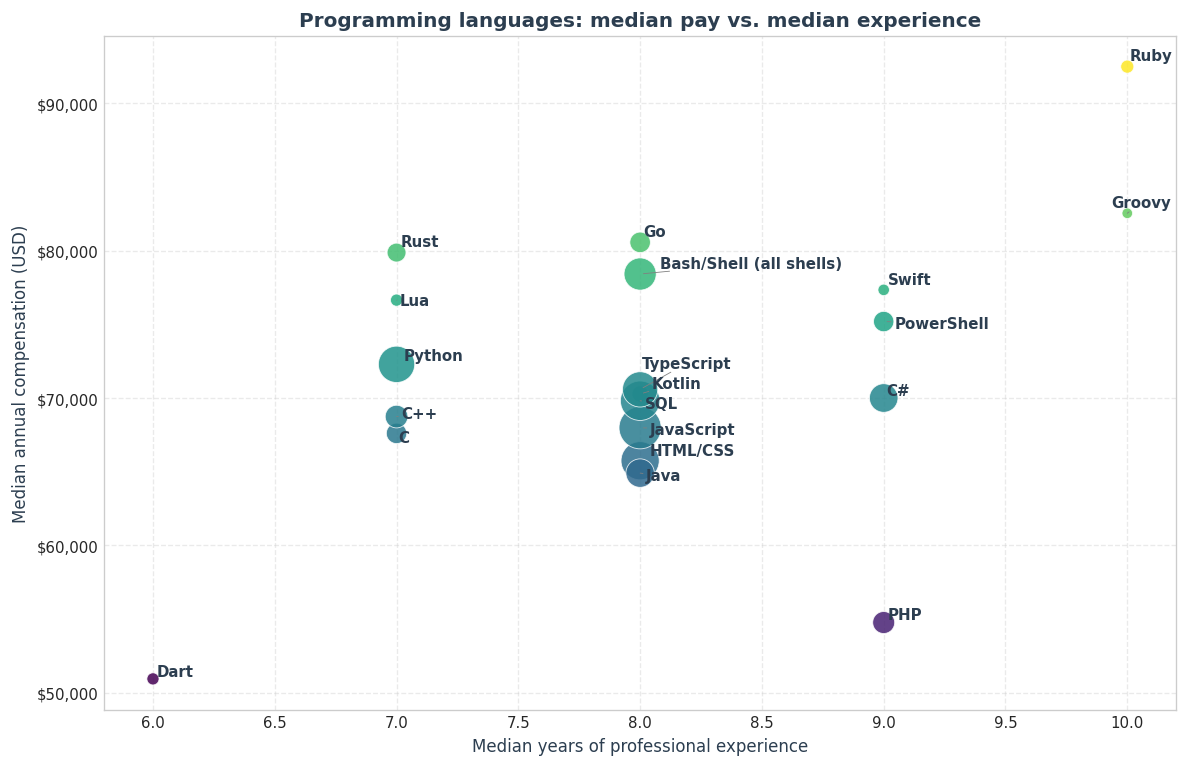

               Language  Median_Comp  Median_Exp  Developer_Count
                   Ruby      92470.0        10.0             1235
                 Groovy      82526.0        10.0              805
                     Go      80555.0         8.0             3032
                   Rust      79861.5         7.0             2566
Bash/Shell (all shells)      78407.0         8.0             7453
                  Swift      77332.0         9.0              947
                    Lua      76637.0         7.0             1067
             PowerShell      75184.0         9.0             2975
                 Python      72284.0         7.0             9503
             TypeScript      70584.0         8.0             8952
                 Kotlin      70275.0         8.0             1957
                     C#      70000.0         9.0             5877
                    SQL      69814.0         8.0            11187
                    C++      68740.0         7.0             3691
          

In [4]:
df_langs = df_clean.dropna(subset=['LanguageHaveWorkedWith']).copy()
df_langs['Language'] = df_langs['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_langs.explode('Language')

top_langs = df_exploded['Language'].value_counts().head(20).index
lang_stats = df_exploded[df_exploded['Language'].isin(top_langs)].groupby('Language').agg(
    Median_Comp=('ConvertedCompYearly', 'median'),
    Median_Exp=('YearsCodePro_num', 'median'),
    Developer_Count=('ResponseId', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(lang_stats['Median_Exp'], lang_stats['Median_Comp'],
           s=lang_stats['Developer_Count'] / 20, c=lang_stats['Median_Comp'],
           cmap='viridis', alpha=0.85, edgecolors='white', linewidths=0.5)

# adjustText spaces the labels apart automatically instead of letting a
# cluster of mid-pay languages (JS, TS, SQL, Java, HTML/CSS) print on top
# of one another.
texts = [ax.text(row['Median_Exp'], row['Median_Comp'], row['Language'], fontsize=9, weight='semibold')
         for _, row in lang_stats.iterrows()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.set_title('Programming languages: median pay vs. median experience')
ax.set_xlabel('Median years of professional experience')
ax.set_ylabel('Median annual compensation (USD)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(lang_stats.sort_values('Median_Comp', ascending=False).to_string(index=False))

Ruby, Groovy, Go, and Rust sit at the top of the pay list. Developers who use them also report more experience: 7 to 10 years at the median, against 6 to 8 years for languages at the bottom of the list. Pay and experience move together across languages, which usually means a confound: people likely aren't paid more for knowing Rust. They're paid more because Rust users tend to be further into their careers. Section 4 checks this directly by putting language flags into a model next to country and experience.

## 3. What Drives Job Satisfaction: Pay or Friction?

`JobSat` in the 2024 survey is a direct 0–10 rating, not a five-point label, so it's used as is. Two other questions get compared against it: whether knowledge silos block people from getting information across the organization (`Knowledge_2`), and whether people can quickly find answers with the tools they already have (`Knowledge_4`). Both are five-point agreement scales, mapped to 1 through 5.

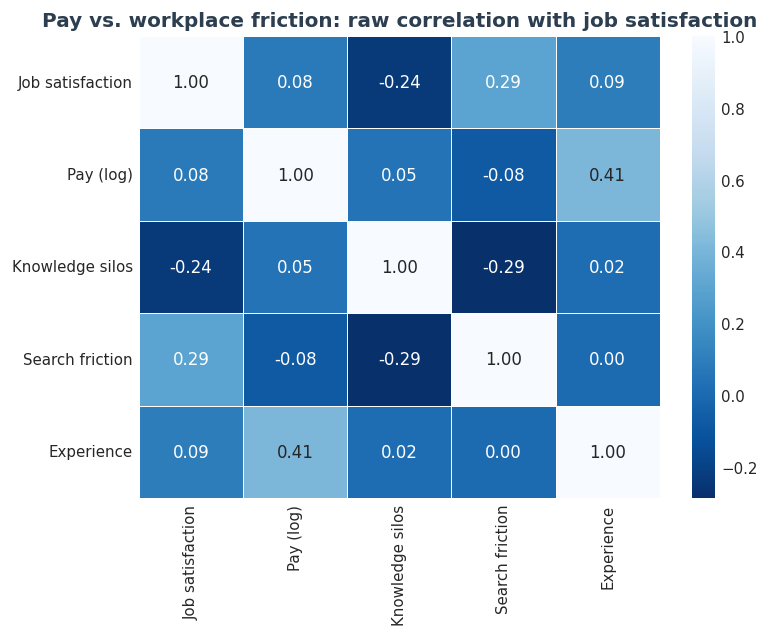

n = 13,640
Silos_Friction     -0.235096
LogComp             0.079019
YearsCodePro_num    0.092563
Search_Friction     0.293829
JobSat_num          1.000000
Name: JobSat_num, dtype: float64


In [5]:
friction_map = {
    'Strongly agree': 5,
    'Agree': 4,
    'Neither agree nor disagree': 3,
    'Disagree': 2,
    'Strongly disagree': 1
}

df_friction = df_clean.dropna(subset=['JobSat', 'Knowledge_2', 'Knowledge_4']).copy()
df_friction['JobSat_num'] = df_friction['JobSat']  # already a native 0-10 scale
df_friction['Silos_Friction'] = df_friction['Knowledge_2'].map(friction_map)    # higher = more agree silos are a problem
df_friction['Search_Friction'] = df_friction['Knowledge_4'].map(friction_map)   # higher = easier to find answers

corr_cols = ['JobSat_num', 'LogComp', 'Silos_Friction', 'Search_Friction', 'YearsCodePro_num']
corr_matrix = df_friction[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='Blues_r',
    fmt='.2f',
    linewidths=0.5,
    xticklabels=['Job satisfaction', 'Pay (log)', 'Knowledge silos', 'Search friction', 'Experience'],
    yticklabels=['Job satisfaction', 'Pay (log)', 'Knowledge silos', 'Search friction', 'Experience']
)
plt.title('Pay vs. workplace friction: raw correlation with job satisfaction')
plt.show()

print(f"n = {len(df_friction):,}")
print(corr_matrix['JobSat_num'].sort_values())

Knowledge silos (r ≈ -0.24) and search friction (r ≈ 0.29) both correlate with satisfaction more strongly than pay does (r ≈ 0.08). None of these are strong correlations on their own; job satisfaction depends on plenty of things this survey doesn't measure. But the relative sizes are the finding: getting unblocked quickly tracks with reported happiness at work more than salary does, at least in this pooled, unadjusted comparison.

### Checking that after controlling for country

The correlation above pools every country together. But a given dollar amount means something different in the US than in India, and country already explains most of the variance in pay (sections 1 and 4). Pooling everyone together without accounting for that can make the pay-satisfaction relationship look weaker than it is, because it compares a well-paid Indian developer's satisfaction to a modestly-paid American developer's satisfaction as if their pay numbers sat on the same scale.

The model below adds country as a control and standardizes every input, so the coefficients are comparable to each other.

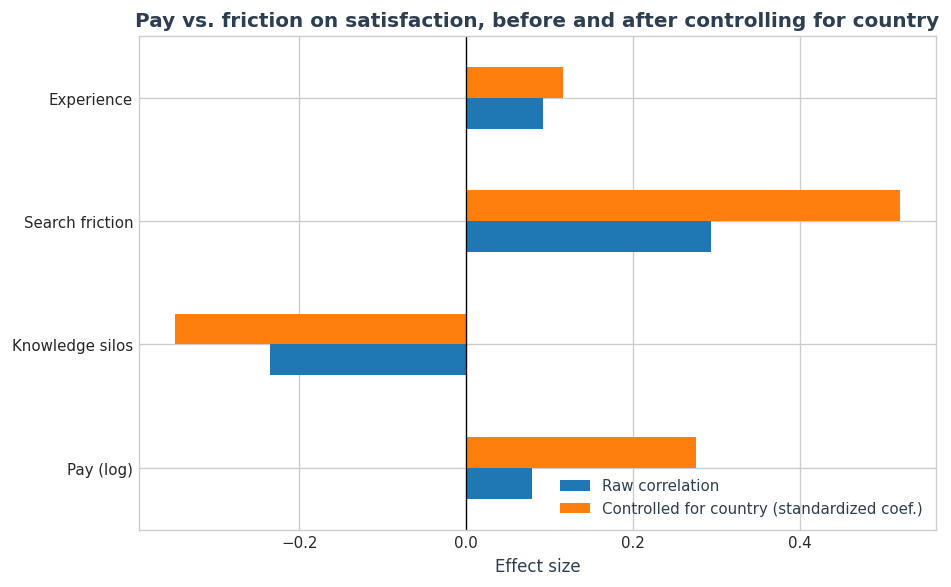

                 Raw correlation  Controlled for country (standardized coef.)
Pay (log)                  0.079                                        0.275
Knowledge silos           -0.235                                       -0.349
Search friction            0.294                                        0.520
Experience                 0.093                                        0.116

Controlled model R2: 0.131  |  n = 13,640


In [6]:
top_ctry_friction = df_friction['Country'].value_counts().head(15).index.tolist()
df_friction['Country_Grouped'] = df_friction['Country'].apply(lambda x: x if x in top_ctry_friction else 'Other')
country_dummies = pd.get_dummies(df_friction['Country_Grouped'], prefix='ctry', drop_first=True)

control_cols = ['LogComp', 'Silos_Friction', 'Search_Friction', 'YearsCodePro_num']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_friction[control_cols]), columns=control_cols, index=df_friction.index)
X_full = pd.concat([X_scaled, country_dummies.astype(float)], axis=1)
y_sat = df_friction['JobSat_num']

control_model = LinearRegression().fit(X_full, y_sat)
controlled_coefs = pd.Series(control_model.coef_, index=X_full.columns)[control_cols]
control_r2 = control_model.score(X_full, y_sat)

raw_corr = df_friction[['JobSat_num'] + control_cols].corr()['JobSat_num'][control_cols]

compare = pd.DataFrame({
    'Raw correlation': raw_corr,
    'Controlled for country (standardized coef.)': controlled_coefs
})
compare.index = ['Pay (log)', 'Knowledge silos', 'Search friction', 'Experience']

fig, ax = plt.subplots(figsize=(8, 5))
compare.plot(kind='barh', ax=ax, color=[PRIMARY_COLOR, ACCENT_COLOR])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pay vs. friction on satisfaction, before and after controlling for country')
ax.set_xlabel('Effect size')
plt.tight_layout()
plt.show()

print(compare.round(3))
print(f"\nControlled model R2: {control_r2:.3f}  |  n = {len(df_friction):,}")

Controlling for country changes the picture. Pay's standardized effect on satisfaction roughly triples, from 0.08 to 0.27. Search friction (0.52) and knowledge silos (-0.35) are still bigger, but the gap between friction and pay shrinks from three-to-four times down to roughly one-and-a-half to two times. Friction still matters more than pay. It just doesn't dominate as much as the raw, pooled number suggested. This controlled model explains about 13% of the variance in satisfaction (R² = 0.13). Most of what makes someone satisfied at work isn't in this dataset: management quality, autonomy, and the actual content of the job all go unmeasured here.

## 4. Building a Pay Model

This section fits two models on log-compensation: a Ridge regression and a Random Forest. Inputs: country (grouped to the top 25, everything else as "Other"), years of experience, education level, remote status, and eight language flags (JavaScript, Python, Java, TypeScript, C#, Go, Rust, SQL). Evaluation uses five-fold cross-validation rather than a single train/test split, so the results aren't sensitive to one lucky or unlucky split.

In [7]:
df_ml = df_clean.dropna(subset=['Country', 'EdLevel', 'RemoteWork', 'YearsCodePro_num', 'LanguageHaveWorkedWith']).copy()

top_countries_list = df_ml['Country'].value_counts().head(25).index.tolist()
df_ml['Country_Grouped'] = df_ml['Country'].apply(lambda x: x if x in top_countries_list else 'Other')

model_languages = ['JavaScript', 'Python', 'Java', 'TypeScript', 'C#', 'Go', 'Rust', 'SQL']
for language in model_languages:
    df_ml[f'lang_{language}'] = df_ml['LanguageHaveWorkedWith'].str.contains(language, regex=False)
lang_cols = [f'lang_{l}' for l in model_languages]

cat_cols = ['Country_Grouped', 'EdLevel', 'RemoteWork']
X = df_ml[['YearsCodePro_num'] + cat_cols + lang_cols]
y = df_ml['LogComp']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), ['YearsCodePro_num']),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('lang', 'passthrough', lang_cols)
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=1.0))])
rf_model = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))])

results = {}
for name, model in [('Ridge', ridge_model), ('Random Forest', rf_model)]:
    oof_log_pred = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)
    dollar_true = 10 ** y
    dollar_pred = 10 ** oof_log_pred
    results[name] = {
        'R2': r2_score(y, oof_log_pred),
        'MAE': mean_absolute_error(dollar_true, dollar_pred),
        'MAPE': mean_absolute_percentage_error(dollar_true, dollar_pred),
        'oof_pred_dollar': dollar_pred
    }

print("Five-fold cross-validated performance:")
print("-" * 58)
for name, r in results.items():
    print(f"{name:<14} R2: {r['R2']:.4f}  |  MAE: ${r['MAE']:,.0f}  |  MAPE: {r['MAPE']:.1%}")

# Fit on the full dataset once more so we have a model object to pull
# feature importances from -- cross_val_predict above only gives predictions,
# not a fitted model.
ridge_model.fit(X, y)
rf_model.fit(X, y)

Five-fold cross-validated performance:
----------------------------------------------------------
Ridge          R2: 0.5388  |  MAE: $30,861  |  MAPE: 52.4%
Random Forest  R2: 0.5581  |  MAE: $30,057  |  MAPE: 51.2%


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

Random Forest edges out Ridge by about two points of R² (0.56 vs. 0.54). That's a small return for a much heavier model. The extra complexity isn't buying much, because the real signal sits in just two features.

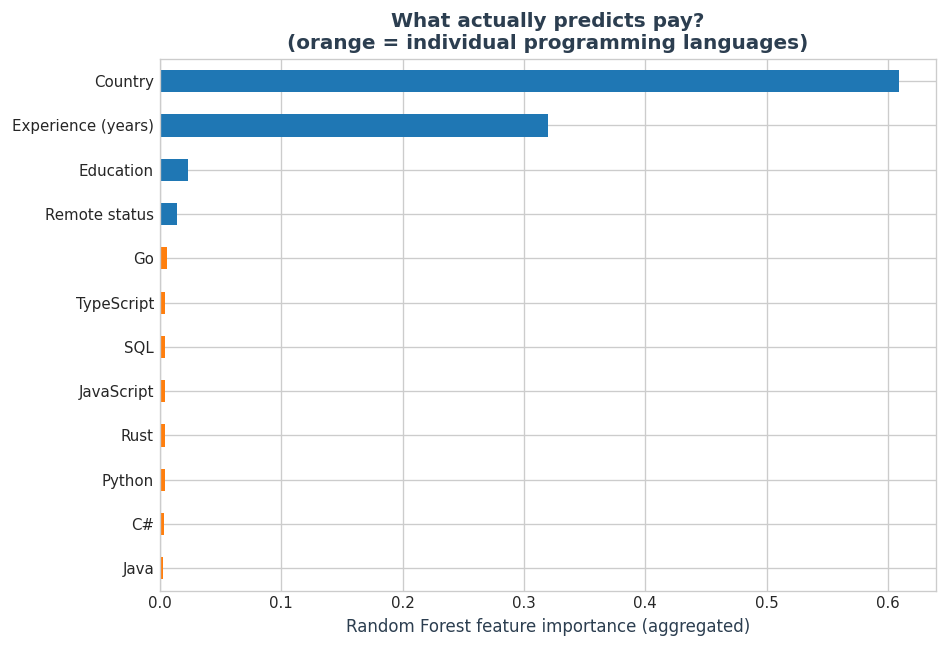

Country               0.609219
Experience (years)    0.319703
Education             0.022916
Remote status         0.014122
Go                    0.006290
TypeScript            0.004540
SQL                   0.004476
JavaScript            0.004401
Rust                  0.004301
Python                0.004201
C#                    0.003603
Java                  0.002228
dtype: float64


In [8]:
cat_feature_names = list(rf_model.named_steps['preprocessor']
                          .named_transformers_['cat'].get_feature_names_out(cat_cols))
all_names = ['YearsCodePro_num'] + cat_feature_names + lang_cols
importances = rf_model.named_steps['regressor'].feature_importances_

agg_importance = {'YearsCodePro_num': importances[0]}
idx = 1
for col in cat_cols:
    n_cats = len(rf_model.named_steps['preprocessor'].named_transformers_['cat']
                 .categories_[cat_cols.index(col)])
    agg_importance[col] = importances[idx: idx + n_cats].sum()
    idx += n_cats
for lang_col in lang_cols:
    agg_importance[lang_col] = importances[idx]
    idx += 1

label_map = {'YearsCodePro_num': 'Experience (years)', 'Country_Grouped': 'Country',
             'EdLevel': 'Education', 'RemoteWork': 'Remote status'}
for l in model_languages:
    label_map[f'lang_{l}'] = l

agg_importance = pd.Series(agg_importance).rename(index=label_map).sort_values()
is_language = [name in model_languages for name in agg_importance.index]

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = [ACCENT_COLOR if lang else PRIMARY_COLOR for lang in is_language]
agg_importance.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Random Forest feature importance (aggregated)')
ax.set_title('What actually predicts pay?\n(orange = individual programming languages)')
plt.tight_layout()
plt.show()

print(agg_importance.sort_values(ascending=False))

Country (about 60% of the model's importance) and years of experience (about 32%) account for roughly 93% of what the Random Forest can explain. Education, remote status, and all eight language flags combined make up the rest. No single language clears 1% of importance. This matches the pattern from section 2: the language pay gaps were riding on country and seniority, not an independent language effect.

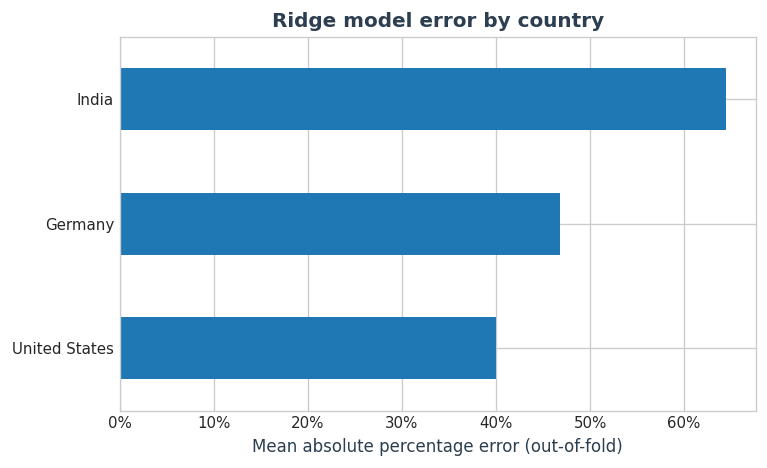

United States    40.0%
Germany          46.8%
India            64.4%
dtype: str


In [9]:
df_ml['pred_dollar_ridge'] = results['Ridge']['oof_pred_dollar']

check_countries = ['United States of America', 'Germany', 'India']
mape_by_country = {}
for c in check_countries:
    sub = df_ml[df_ml['Country'] == c]
    mape_by_country[c] = mean_absolute_percentage_error(10 ** sub['LogComp'], sub['pred_dollar_ridge'])

mape_series = pd.Series(mape_by_country).rename(index=country_labels).sort_values()

fig, ax = plt.subplots(figsize=(6.5, 4))
mape_series.plot(kind='barh', ax=ax, color=PRIMARY_COLOR)
ax.set_xlabel('Mean absolute percentage error (out-of-fold)')
ax.set_title('Ridge model error by country')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print(mape_series.map(lambda x: f'{x:.1%}'))

Both models explain a good share of the variance (R² above 0.5), but explaining variance and making a reliable single prediction are different things. On a typical prediction, the Ridge model is off by about 52% of the true salary. That error isn't spread evenly: about 40% for US respondents, 47% for German respondents, 64% for Indian respondents. The model is least reliable exactly where the dollar amounts are smallest and, in local terms, matter the most.

## Limitations

A few things worth keeping in mind when reading any of this:

- Stack Overflow survey respondents are self-selected. They skew toward people who are online, English-comfortable, and already engaged with the Stack Overflow ecosystem. That's not the same population as "all developers worldwide."
- `ConvertedCompYearly` is Stack Overflow's own currency conversion, done at a point-in-time exchange rate. For volatile currencies, that conversion adds noise this analysis can't remove.
- Everything here is correlational. Nothing in this notebook establishes that friction causes lower satisfaction, or that a language causes higher pay, even after controlling for confounds. Controlling for country and experience rules out two specific alternative explanations. It doesn't rule out all of them.
- `LanguageHaveWorkedWith` means "worked with in the past year," not "primary language" or "years of use." Someone who touched Rust once counts the same as someone who uses it daily.

## Summary of Findings

Back to the original questions:

**Do technical choices and remote work drive higher pay, or is it just experience and location?**
Mostly experience and location. Rust and Go users report higher pay, but they're also more senior; once country and experience are in the model, no single language holds much independent weight. Remote work shows the same pattern: it looks like a premium until you notice remote workers are more senior too. Tech stack, education, and remote status barely move the model's predictions once location and experience are already accounted for.

**How much of pay can we actually explain?**
About half. Country and experience together account for roughly 54% of the variance in a baseline linear model (R² ≈ 0.54). The rest comes down to things this survey doesn't capture: negotiation, industry, company stage, equity.

**What actually drives job satisfaction?**
Friction, more than pay. People who get blocked by knowledge silos or can't find answers quickly report lower satisfaction than pay differences alone would predict, and that holds even after controlling for country. High earners stuck in high-friction environments still report less satisfaction than lower earners working in smoother setups.

**How well can models predict salary, and where do they struggle?**
Decently, not great. A five-fold cross-validated Random Forest reaches R² = 0.56, barely ahead of a Ridge regression at 0.54, and the extra complexity buys almost nothing. Even the better model misses by about 50% on a typical prediction, and it's worse for developers outside the US: the model struggles most exactly where getting the number right matters most.

## Conclusion

Two things decide most of what a developer gets paid: where they live and how long they've been working. Learning Rust or negotiating a remote role can look like a shortcut to more money, but the data says it usually just means someone's been in the industry longer.

Predicting an individual's salary from this data only gets you so far. Location and experience explain about half of it; the rest is negotiation, employer, and other things this survey never asked about. And when it comes to being happy at work, pay isn't the main driver: smooth daily workflows matter more than a slightly bigger paycheck.
